<h1>COVID-19 Data Exploraion for G8 countries</h1>

#### Step 1 and 2 Importing and Downloading the datasets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Extracting the datasets - Dataset is filtered to G8 countries.
cases = pd.read_csv(
    "daily-new-confirmed-covid-19-cases-per-million-people.csv"
)

deaths = pd.read_csv(
    "daily-new-confirmed-covid-19-deaths-per-million-people.csv"
)

vaccines = pd.read_csv(
    "daily-share-of-the-population-receiving-a-first-covid-19-vaccine-dose.csv"
)

In [3]:
# Summary for Cases
print(cases.head())
print(cases.columns)
print(cases.info())

   Entity Code         Day  New cases (per 1M)
0  Canada  CAN  2020-12-14           169.20773
1  Canada  CAN  2020-12-15           167.71002
2  Canada  CAN  2020-12-16           168.56375
3  Canada  CAN  2020-12-17           169.92899
4  Canada  CAN  2020-12-18           170.37425
Index(['Entity', 'Code', 'Day', 'New cases (per 1M)'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9354 entries, 0 to 9353
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Entity              9354 non-null   object 
 1   Code                9354 non-null   object 
 2   Day                 9354 non-null   object 
 3   New cases (per 1M)  9354 non-null   float64
dtypes: float64(1), object(3)
memory usage: 292.4+ KB
None


In [4]:
# Summary for Deaths
print(deaths.head())
print(deaths.columns)
print(deaths.info())

   Entity Code         Day  New deaths (per 1M)
0  Canada  CAN  01/03/2020                  0.0
1  Canada  CAN  02/03/2020                  0.0
2  Canada  CAN  03/03/2020                  0.0
3  Canada  CAN  04/03/2020                  0.0
4  Canada  CAN  05/03/2020                  0.0
Index(['Entity', 'Code', 'Day', 'New deaths (per 1M)'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15556 entries, 0 to 15555
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Entity               15556 non-null  object 
 1   Code                 15556 non-null  object 
 2   Day                  15556 non-null  object 
 3   New deaths (per 1M)  15556 non-null  float64
dtypes: float64(1), object(3)
memory usage: 486.3+ KB
None


In [5]:
# Summary for Vaccinations
print(vaccines.head())
print(vaccines.columns)
print(vaccines.info())

   Entity Code         Day  \
0  Canada  CAN  2020-12-15   
1  Canada  CAN  2020-12-16   
2  Canada  CAN  2020-12-17   
3  Canada  CAN  2020-12-18   
4  Canada  CAN  2020-12-19   

   People vaccinated (daily, 7-day average, per million people)  
0                                           0.001857             
1                                           0.003892             
2                                           0.006248             
3                                           0.007272             
4                                           0.006372             
Index(['Entity', 'Code', 'Day',
       'People vaccinated (daily, 7-day average, per million people)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 4 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Enti

It is noted from checking the Day columns all need to be converted into a Date type format.

In [10]:
cases['Day'] = pd.to_datetime(cases['Day'], dayfirst=True)
deaths['Day'] = pd.to_datetime(deaths['Day'], dayfirst=True)
vaccines['Day'] = pd.to_datetime(vaccines['Day'], dayfirst=True)

#Validation

print(cases.dtypes)
print(deaths.dtypes)
print(vaccines.dtypes)

Entity                        object
Code                          object
Day                   datetime64[ns]
New cases (per 1M)           float64
dtype: object
Entity                         object
Code                           object
Day                    datetime64[ns]
New deaths (per 1M)           float64
dtype: object
Entity                                                                  object
Code                                                                    object
Day                                                             datetime64[ns]
People vaccinated (daily, 7-day average, per million people)           float64
dtype: object


In [11]:
#Checking the data for NULLS
print(cases.isnull().sum())
print(deaths.isnull().sum())
print(vaccines.isnull().sum())

Entity                0
Code                  0
Day                   0
New cases (per 1M)    0
dtype: int64
Entity                 0
Code                   0
Day                    0
New deaths (per 1M)    0
dtype: int64
Entity                                                          0
Code                                                            0
Day                                                             0
People vaccinated (daily, 7-day average, per million people)    0
dtype: int64


##### Data Loading & Inspection

The datasets were loaded using pandas and inspected to identify key variables and data structures. Each dataset contains time series information for G8 countries, including daily COVID-19 cases, deaths, and vaccination progress.

The Day column was converted into datetime format to support time series analysis and visualisation. Initial inspection also included reviewing column names, data types, and missing values to ensure data quality before analysis.

#### Step 3: Visual findings of cases, deaths and vaccination rates (per millions)

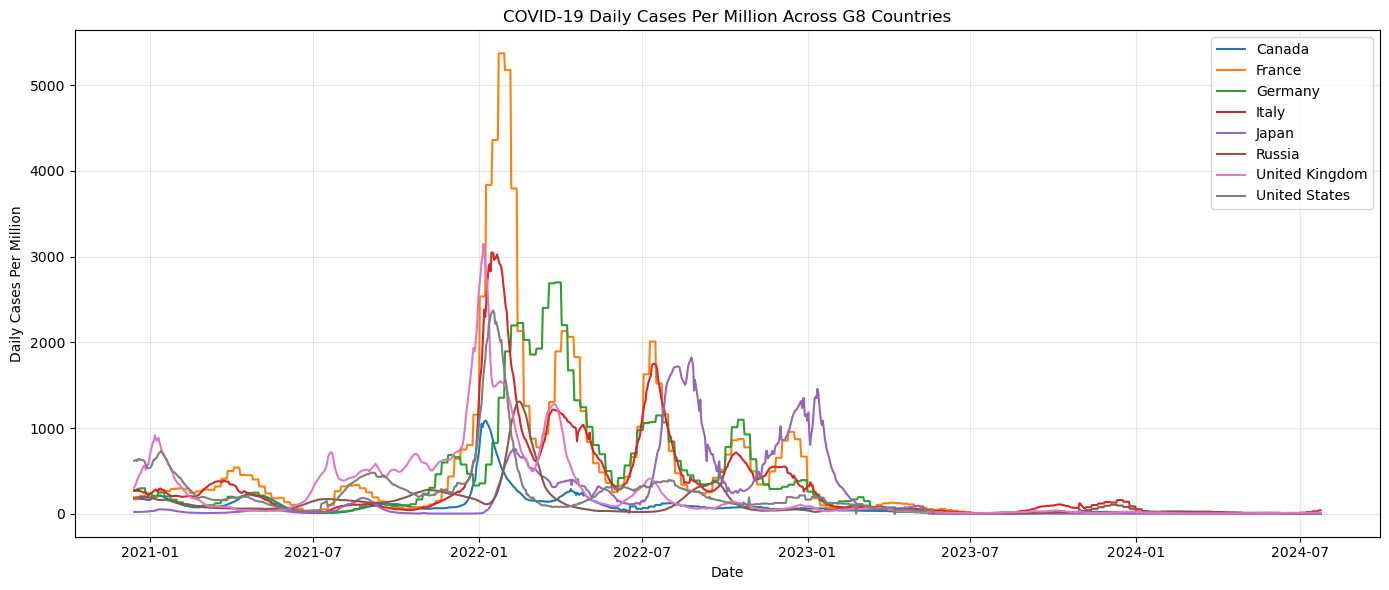

In [13]:
plt.figure(figsize = (14, 6))

for country in cases['Entity'].unique():
    country_data = cases[cases['Entity'] == country]

    plt.plot(
        country_data['Day'],
        country_data.iloc[:,-1],
        label = country
    )

plt.title("COVID-19 Daily Cases Per Million Across G8 Countries")
plt.xlabel("Date")
plt.ylabel("Daily Cases Per Million")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

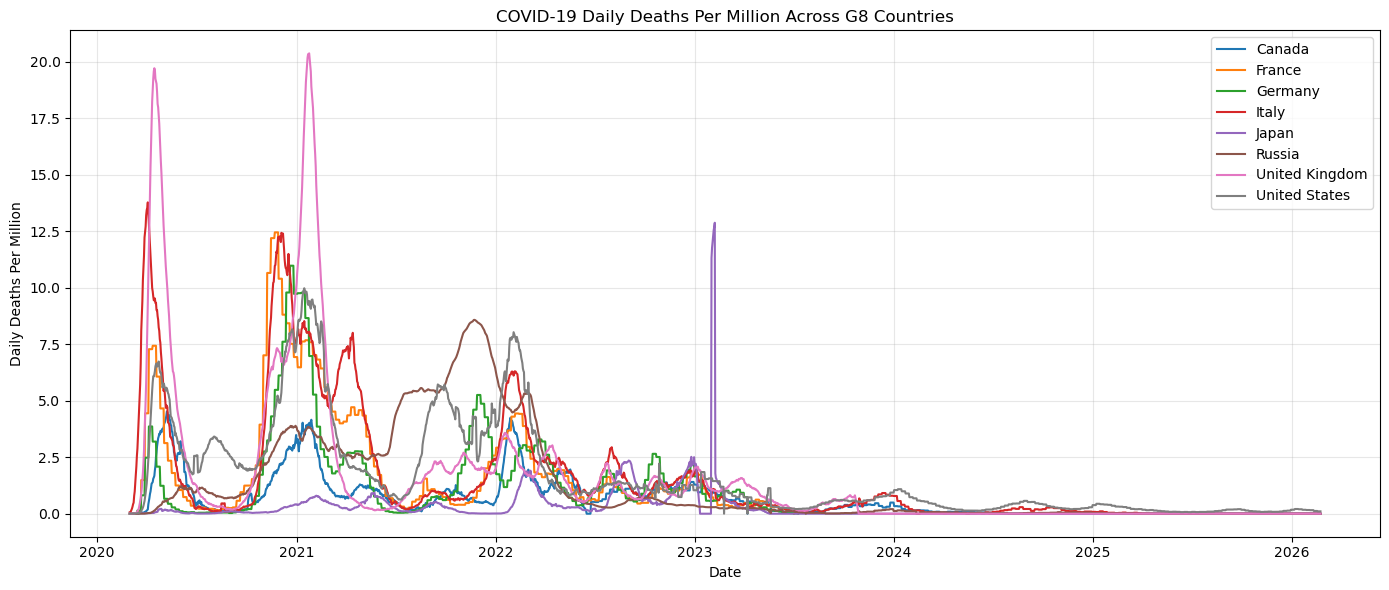

In [14]:
plt.figure(figsize = (14, 6))

for country in deaths['Entity'].unique():
    country_data = deaths[deaths['Entity'] == country]

    plt.plot(
        country_data['Day'],
        country_data.iloc[:,-1],
        label = country
    )

plt.title("COVID-19 Daily Deaths Per Million Across G8 Countries")
plt.xlabel("Date")
plt.ylabel("Daily Deaths Per Million")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

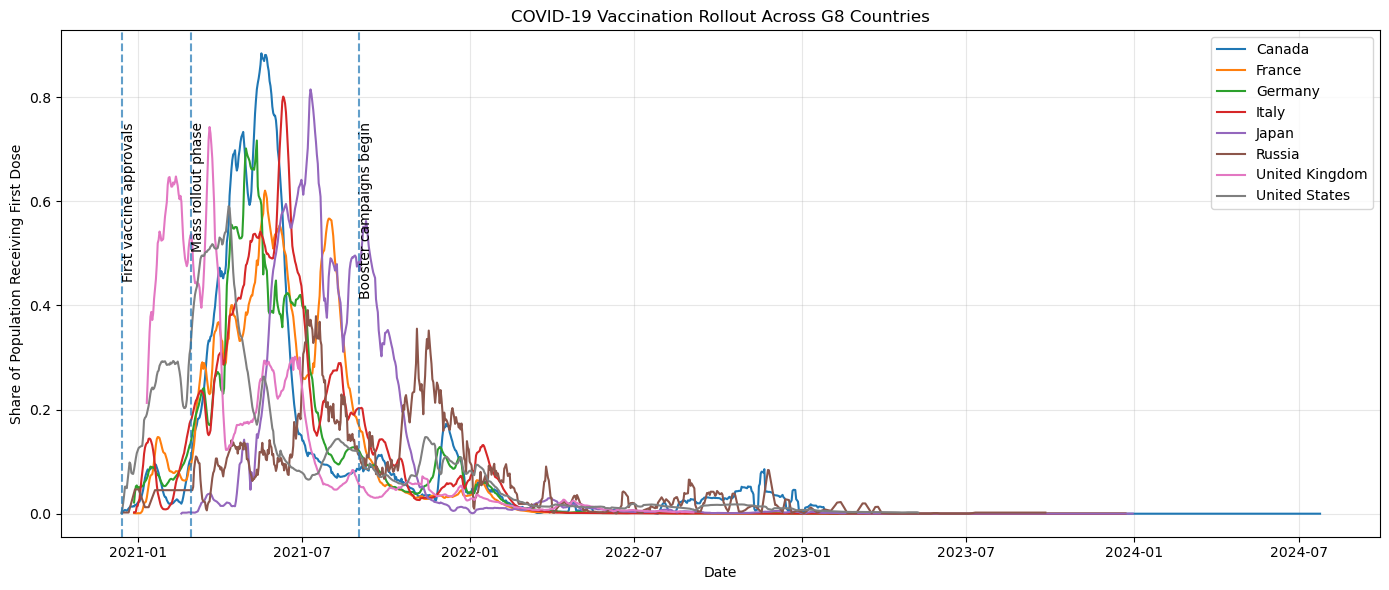

In [27]:
plt.figure(figsize=(14,6))

for country in vaccines['Entity'].unique():

    country_data = vaccines[
        vaccines['Entity'] == country
    ]

    plt.plot(
        country_data['Day'],
        country_data.iloc[:, -1],
        label=country
    )

# Key vaccination-related events
events = {
    'First vaccine approvals': '2020-12-15',
    'Mass rollout phase': '2021-03-01',
    'Booster campaigns begin': '2021-09-01'
}

for label, date in events.items():

    event_date = pd.to_datetime(date)

    plt.axvline(
        event_date,
        linestyle='--',
        alpha=0.7
    )

    plt.text(
        event_date,
        vaccines.iloc[:, -1].max() * 0.85,
        label,
        rotation=90,
        verticalalignment='top'
    )

plt.title("COVID-19 Vaccination Rollout Across G8 Countries")
plt.xlabel("Date")
plt.ylabel("Share of Population Receiving First Dose")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [18]:
#Rolling averages
cases['RollingAvg'] = (
    cases
    .groupby('Entity')[
        'New cases (per 1M)'
    ]
    .transform(lambda x: x.rolling(7).mean())
)

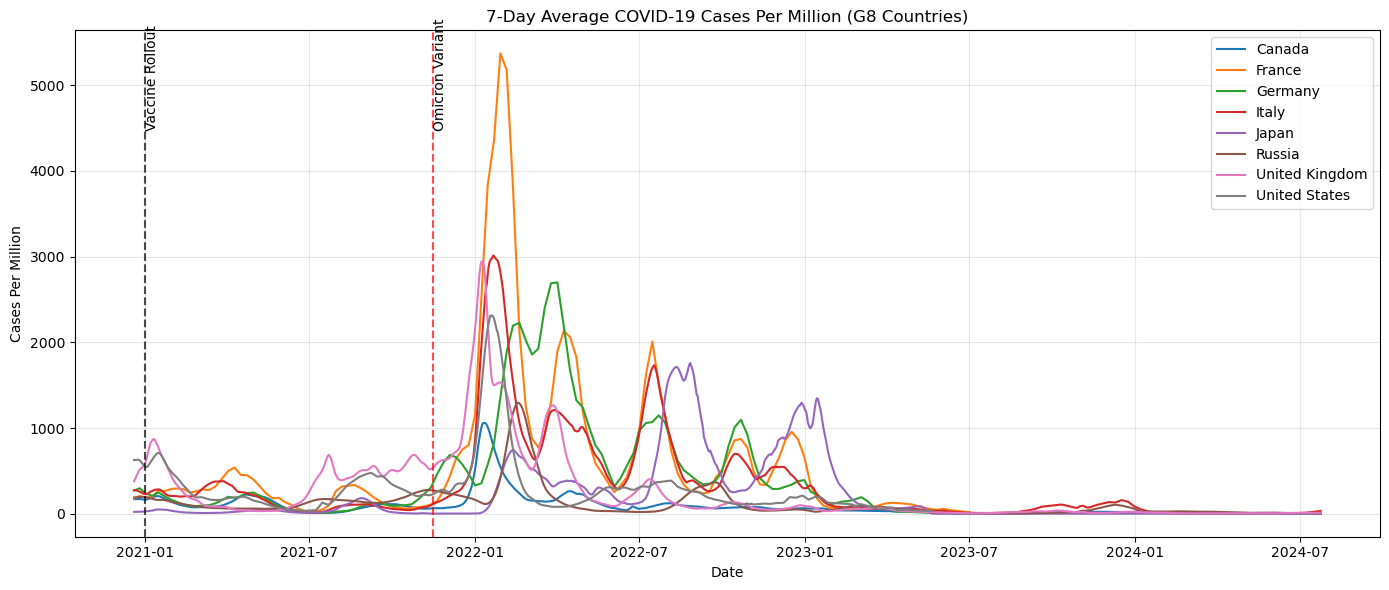

In [25]:
plt.figure(figsize=(14,6))

for country in cases['Entity'].unique():

    country_data = cases[
        cases['Entity'] == country
    ]

    plt.plot(
        country_data['Day'],
        country_data['RollingAvg'],
        label=country
    )

# Vaccine rollout
plt.axvline(
    pd.to_datetime('2021-01-01'),
    color='black',
    linestyle='--',
    alpha=0.7
)

# Omicron emergence
plt.axvline(
    pd.to_datetime('2021-11-15'),
    color='red',
    linestyle='--',
    alpha=0.7
)

# Annotation labels
plt.text(
    pd.to_datetime('2021-01-01'),
    4500,
    'Vaccine Rollout',
    rotation=90
)

plt.text(
    pd.to_datetime('2021-11-15'),
    4500,
    'Omicron Variant',
    rotation=90
)

plt.title("7-Day Average COVID-19 Cases Per Million (G8 Countries)")
plt.xlabel("Date")
plt.ylabel("Cases Per Million")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [20]:
deaths['RollingAvg'] = (
    deaths
    .groupby('Entity')[
        'New deaths (per 1M)'
    ]
    .transform(lambda x: x.rolling(7).mean())
)

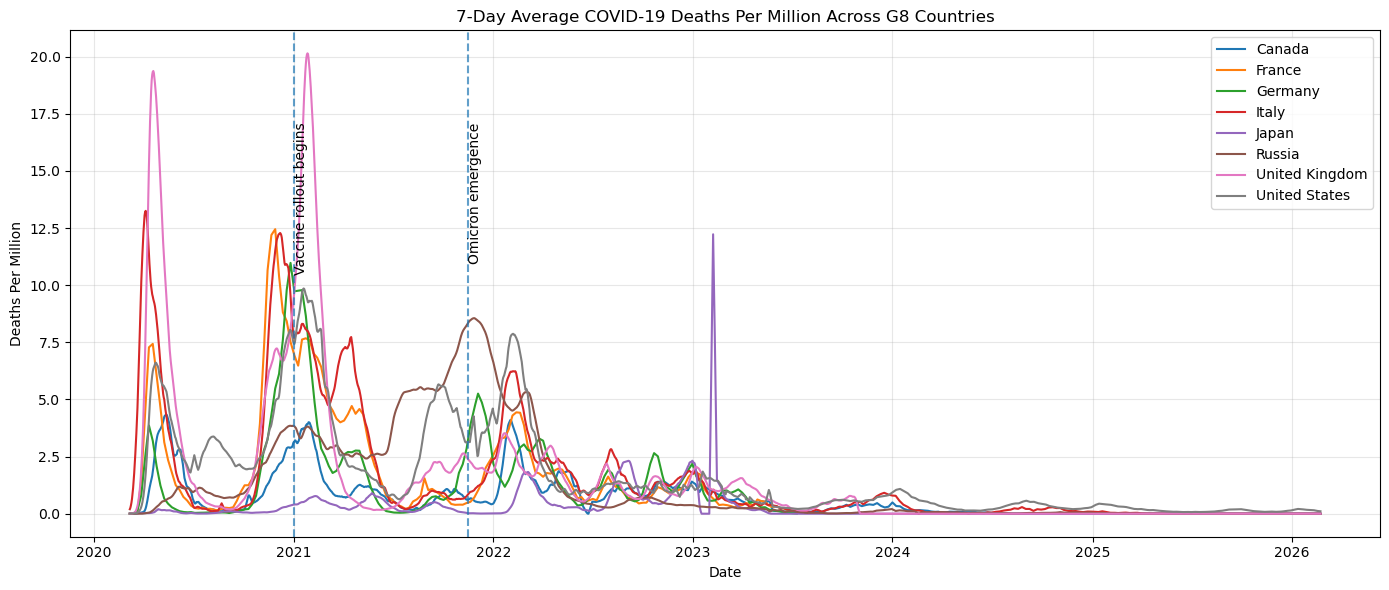

In [26]:
plt.figure(figsize=(14,6))

for country in deaths['Entity'].unique():

    country_data = deaths[
        deaths['Entity'] == country
    ]

    plt.plot(
        country_data['Day'],
        country_data['RollingAvg'],
        label=country
    )

# Key event annotations
events = {
    'Vaccine rollout begins': '2021-01-01',
    'Omicron emergence': '2021-11-15'
}

for label, date in events.items():

    event_date = pd.to_datetime(date)

    plt.axvline(
        event_date,
        linestyle='--',
        alpha=0.7
    )

    plt.text(
        event_date,
        deaths['RollingAvg'].max() * 0.85,
        label,
        rotation=90,
        verticalalignment='top'
    )

plt.title("7-Day Average COVID-19 Deaths Per Million Across G8 Countries")
plt.xlabel("Date")
plt.ylabel("Deaths Per Million")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

The smoothed trends reveal clearer pandemic waves across G8 countries and reduce short-term reporting volatility. While infection rates increased sharply during later waves, particularly during the Omicron period, death rates generally remained lower relative to earlier waves, coinciding with large-scale vaccination rollout across all G8 nations.

The vaccination rollout trends reveal significant differences in timing and acceleration across G8 countries. The United Kingdom and United States began large-scale vaccination campaigns earlier, while countries such as Japan experienced slower initial rollout followed by rapid acceleration later in 2021. Canada demonstrated one of the strongest sustained vaccination growth periods among G8 nations.

The annotated 7-day rolling average highlights key pandemic phases across G8 countries. Early lockdown periods followed the WHO pandemic declaration in March 2020, while vaccine rollout began around early 2021. The largest case surges occur after the emergence of Omicron in late 2021, particularly across European G8 countries.

The smoothed deaths trend highlights the severe mortality impact of the early pandemic waves across several G8 countries, particularly the United Kingdom and Italy. Following vaccine rollout in early 2021, later infection waves generally resulted in lower relative death rates despite large increases in reported cases during the Omicron period.

#### Step 5 Deaths and Vaccination per 100,000 

In [28]:
deaths['Deaths per 100k'] = (deaths['New deaths (per 1M)'] / 10)

In [30]:
vaccines['Vaccinated per 100k'] = (vaccines['People vaccinated (daily, 7-day average, per million people)'] / 10)           

All metrics were standardised to rates per 100,000 people to improve interpretability and maintain consistency across datasets. Since the original datasets were already normalised per million population, conversion to per-100,000 rates was performed by dividing values by 10.

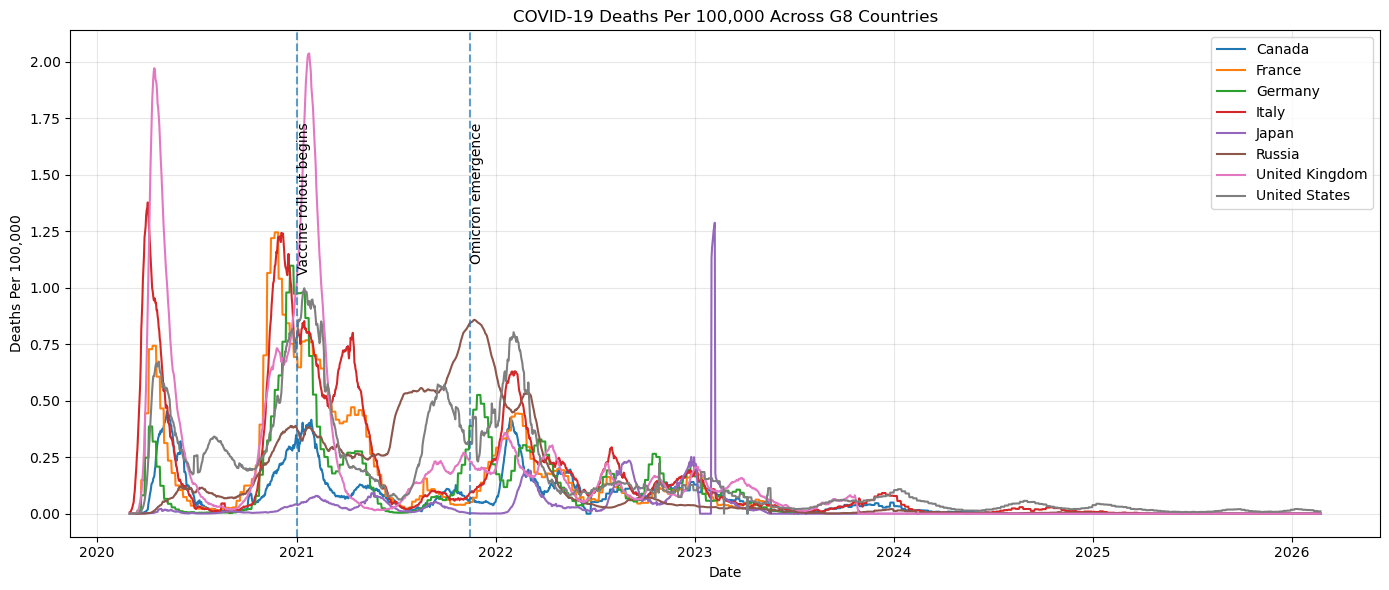

In [35]:
plt.figure(figsize=(14,6))

for country in deaths['Entity'].unique():

    country_data = deaths[
        deaths['Entity'] == country
    ]

    plt.plot(
        country_data['Day'],
        country_data['Deaths per 100k'],
        label=country
    )

# Annotations
events = {
    'Vaccine rollout begins': '2021-01-01',
    'Omicron emergence': '2021-11-15'
}

for label, date in events.items():

    event_date = pd.to_datetime(date)

    plt.axvline(
        event_date,
        linestyle='--',
        alpha=0.7
    )

    plt.text(
        event_date,
        deaths['Deaths per 100k'].max() * 0.85,
        label,
        rotation=90,
        verticalalignment='top'
    )

plt.title("COVID-19 Deaths Per 100,000 Across G8 Countries")
plt.xlabel("Date")
plt.ylabel("Deaths Per 100,000")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

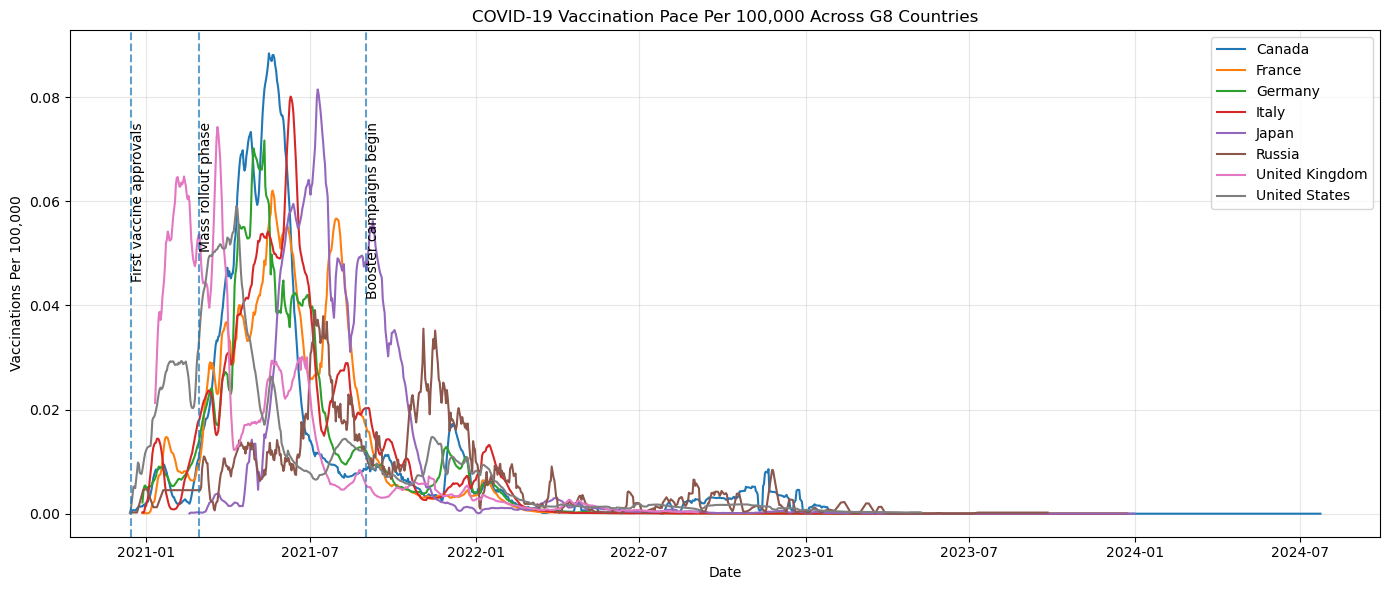

In [36]:
plt.figure(figsize=(14,6))

for country in vaccines['Entity'].unique():

    country_data = vaccines[
        vaccines['Entity'] == country
    ]

    plt.plot(
        country_data['Day'],
        country_data['Vaccinated per 100k'],
        label=country
    )

# Annotations
events = {
    'First vaccine approvals': '2020-12-15',
    'Mass rollout phase': '2021-03-01',
    'Booster campaigns begin': '2021-09-01'
}

for label, date in events.items():

    event_date = pd.to_datetime(date)

    plt.axvline(
        event_date,
        linestyle='--',
        alpha=0.7
    )

    plt.text(
        event_date,
        vaccines['Vaccinated per 100k'].max() * 0.85,
        label,
        rotation=90,
        verticalalignment='top'
    )

plt.title("COVID-19 Vaccination Pace Per 100,000 Across G8 Countries")
plt.xlabel("Date")
plt.ylabel("Vaccinations Per 100,000")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

To improve interpretability and support fair comparisons across countries, COVID-19 death and vaccination metrics were standardised to rates per 100,000 people. Since the original datasets were already normalised per million population, conversion to per-100,000 rates was performed by dividing the values by 10.

Annotated multi-country time series charts were then created to compare trends across G8 nations. The visualisations highlighted major pandemic events including the WHO pandemic declaration, vaccine rollout periods, and the emergence of the Omicron variant.

The analysis showed that although many G8 countries experienced large infection waves during late 2021 and early 2022, death rates generally remained lower relative to earlier pandemic waves. This trend coincided with large-scale vaccination campaigns, suggesting that vaccine rollout contributed to reducing severe outcomes despite continued transmission.

Differences in vaccination rollout speed were also visible across countries. The United Kingdom and Canada demonstrated rapid early rollout phases, while Japan showed a slower initial rollout followed by strong acceleration later in 2021.

#### Step 5 Creating a multi-country comparison chart.

In [39]:
# Average deaths per 100k
avg_deaths = (
    deaths.groupby('Entity')['Deaths per 100k']
    .mean()
    .sort_values(ascending=False)
)

print(avg_deaths)

Entity
France            0.214392
Germany           0.169587
United States     0.166070
United Kingdom    0.155807
Italy             0.152388
Russia            0.127098
Canada            0.065562
Japan             0.027363
Name: Deaths per 100k, dtype: float64


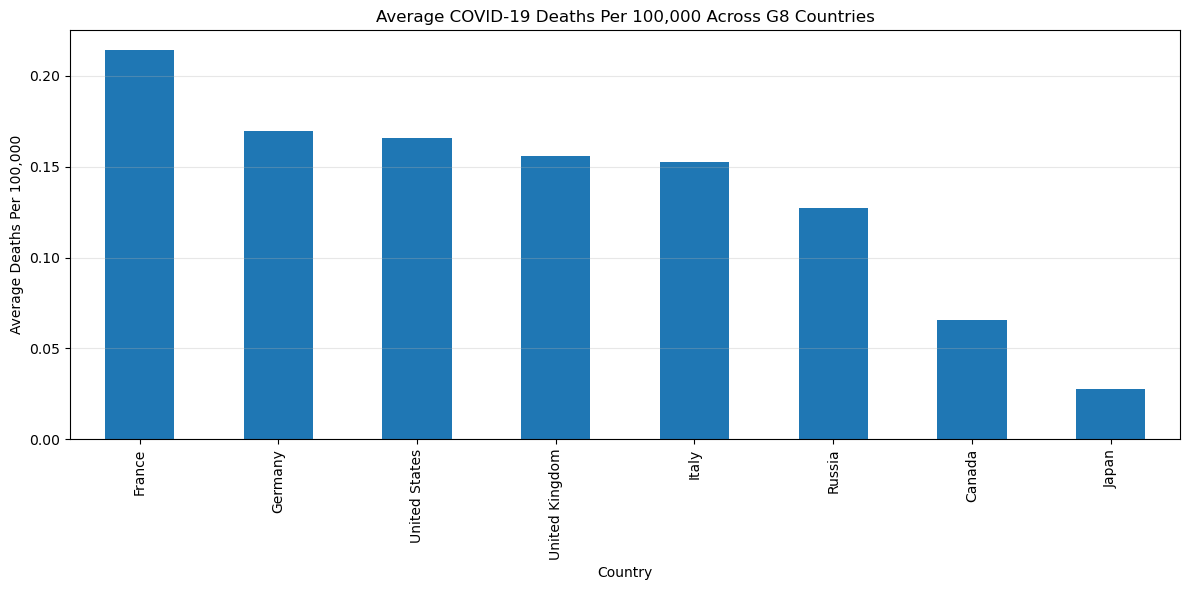

In [41]:
plt.figure(figsize=(12,6))

avg_deaths.plot(kind='bar')

plt.title("Average COVID-19 Deaths Per 100,000 Across G8 Countries")
plt.xlabel("Country")
plt.ylabel("Average Deaths Per 100,000")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [40]:
# Average vaccine pace per 100k
avg_vaccinations = (
    vaccines.groupby('Entity')['Vaccinated per 100k']
    .mean()
    .sort_values(ascending=False)
)

print(avg_vaccinations)

Entity
United Kingdom    0.012693
United States     0.009026
Japan             0.008004
Italy             0.007832
France            0.007562
Germany           0.007080
Canada            0.006791
Russia            0.006027
Name: Vaccinated per 100k, dtype: float64


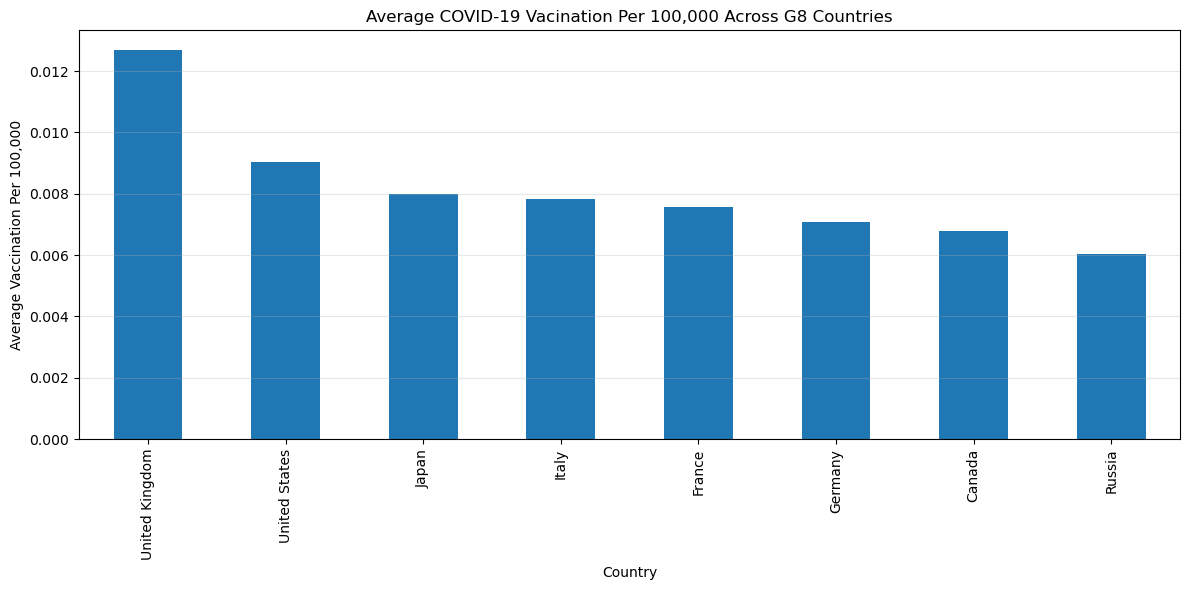

In [42]:
plt.figure(figsize=(12,6))

avg_vaccinations.plot(kind='bar')

plt.title("Average COVID-19 Vacination Per 100,000 Across G8 Countries")
plt.xlabel("Country")
plt.ylabel("Average Vaccination Per 100,000")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Comparative analysis of average COVID-19 death rates per 100,000 revealed substantial variation across G8 countries. France and Germany recorded the highest average mortality rates within the analysed period, while Japan and Canada maintained comparatively lower average death rates.

Vaccination rollout comparisons showed that the United Kingdom and United States achieved some of the strongest average vaccination rates during the rollout period. Japan demonstrated a slower initial rollout followed by significant acceleration later in 2021.

When combined with the earlier time series analysis, the results suggest that widespread vaccination rollout coincided with lower relative mortality during later pandemic waves, particularly during the Omicron period. However, differences in national outcomes were also likely influenced by healthcare capacity, demographic factors, public health policies, and reporting practices.

#### Step 6 Final Summary

##### Final Findings Summary

This project explored COVID-19 trends across G8 countries using public datasets from Our World in Data. The analysis focused on daily confirmed cases, deaths, and vaccination rollout trends, using time series visualisations, rolling averages, annotated charts, and standardised population-based metrics.

The results showed clear differences in pandemic trajectories across G8 nations. Countries such as the United Kingdom, France, and the United States experienced multiple large infection waves, particularly during the emergence of the Omicron variant in late 2021. Japan generally maintained lower case and death rates during earlier phases of the pandemic but experienced a delayed increase during later waves.

Rolling-average visualisations improved readability by smoothing reporting noise and revealing clearer long-term trends. The annotated charts also highlighted major pandemic milestones, including the WHO pandemic declaration, vaccine rollout periods, and the emergence of Omicron.

Comparative analysis of average death rates per 100,000 people showed that France and Germany recorded the highest average mortality rates within the analysed period, while Japan and Canada maintained comparatively lower mortality levels. Vaccination rollout comparisons indicated that the United Kingdom and United States achieved some of the strongest early vaccination rollout rates, while Japan demonstrated a slower initial rollout followed by significant acceleration later in 2021.

Overall, the analysis suggests that although later pandemic waves produced extremely large infection surges across many G8 countries, death rates generally remained lower relative to earlier waves. This trend coincided with widespread vaccination rollout and may reflect the combined impact of vaccination campaigns, improved treatment strategies, prior immunity, and evolving public health responses.

The project demonstrated the value of time series analysis, rolling averages, and annotated visualisations for communicating complex public health trends in a clear and interpretable manner.